In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor 


In [2]:
data = pd.read_excel('Combined data set with Abraham parameters.xlsx', header=1)
#data = pd.read_excel('Combined data set with Abraham parameters-mmol-Mod-To CD.xlsx', header=1)
data.columns

Index(['S. No. ', 'Dye ', 'SSA', 'PV', 'PS', 'dye/AC (conc)',
       'Molar dye/AC (conc)', 'pH', 'temp. 0C', 'equlbm time (h)',
       'Adsorption capacity (mg/g)', 'E', 'S', 'A', 'B', 'V', 'L',
       'Reference'],
      dtype='object')

In [3]:
df_dict = {key:group for key, group in data.groupby('Dye ')}

data_MB = df_dict['MB']
data_MO = df_dict['MO']

In [4]:
# Column names to remove (ensure they match exactly as in your DataFrame)
columns_to_drop = ['S. No. ', 'Dye ', 'E', 'S', 'A', 'B', 'V', 'dye/AC (conc)', 'L', 'Reference']

# Drop the specified columns if they exist
data_MB = data_MB.drop(columns=[col for col in columns_to_drop if col in data_MB.columns])

# Optional: verify the result
print("Columns after removal:")
print(data_MB.columns.tolist())

# Now data_MB contains only the remaining columns
data_MB

Columns after removal:
['SSA', 'PV', 'PS', 'Molar dye/AC (conc)', 'pH', 'temp. 0C', 'equlbm time (h)', 'Adsorption capacity (mg/g)']


,SSA,PV,PS,Molar dye/AC (conc),pH,temp. 0C,equlbm time (h),Adsorption capacity (mg/g)
0,904.6000,0.677000,2.990000,1.083320,11.0,25,2.000,526.30
1,64.4152,0.056948,3.540000,0.007816,9.0,25,1.000,80.00
2,510.0000,0.330000,2.640000,0.781616,8.0,30,3.000,212.76
3,249.0000,0.133000,3.090000,0.130269,6.0,25,1.670,144.90
4,1306.3100,0.960000,3.220000,0.625293,7.0,30,2.670,318.00
5,2869.0000,1.960000,2.000000,0.781616,11.0,30,0.167,968.74
6,756.3000,0.376000,11.300000,0.781616,10.0,50,2.000,195.20
7,168.0000,0.212000,1.840000,0.093794,9.0,25,1.000,32.51
8,123.8380,0.068130,2.600000,0.625293,11.0,25,3.330,200.00
9,1113.3000,0.660700,2.370000,1.250586,6.3,25,2.000,435.00


In [5]:
# After dropping unwanted columns, proceed to split into features (data_x) and target (data_y)

# Extract all columns except the last one as features (data_x)
data_x = data_MB.iloc[:, :-1]  # All rows, all columns except the last

# Extract the last column as target (data_y)
data_y = data_MB.iloc[:, -1]   # All rows, only the last column


data_x

,SSA,PV,PS,Molar dye/AC (conc),pH,temp. 0C,equlbm time (h)
0,904.6000,0.677000,2.990000,1.083320,11.0,25,2.000
1,64.4152,0.056948,3.540000,0.007816,9.0,25,1.000
2,510.0000,0.330000,2.640000,0.781616,8.0,30,3.000
3,249.0000,0.133000,3.090000,0.130269,6.0,25,1.670
4,1306.3100,0.960000,3.220000,0.625293,7.0,30,2.670
5,2869.0000,1.960000,2.000000,0.781616,11.0,30,0.167
6,756.3000,0.376000,11.300000,0.781616,10.0,50,2.000
7,168.0000,0.212000,1.840000,0.093794,9.0,25,1.000
8,123.8380,0.068130,2.600000,0.625293,11.0,25,3.330
9,1113.3000,0.660700,2.370000,1.250586,6.3,25,2.000


In [6]:
data_y

0      526.30
1       80.00
2      212.76
3      144.90
4      318.00
5      968.74
6      195.20
7       32.51
8      200.00
9      435.00
10     274.62
11     955.25
12     220.51
13     531.52
14     290.00
15     498.95
16      96.20
17     430.64
18     235.00
19     194.40
20     269.30
21     458.00
22     500.00
23     250.01
24     400.00
25      15.50
26     716.00
27     325.80
28      72.00
29    1000.00
30     116.28
31      13.00
32      44.00
33     224.00
34     985.50
35     271.00
36     278.55
37     284.90
38     299.40
39     644.00
40     369.00
41    2080.50
42    2251.00
43    1930.00
44    2045.00
45    1758.00
46     380.23
47     434.78
48     315.46
49      79.31
50     160.36
51     357.14
52     250.00
53      37.00
54     296.00
55      87.00
Name: Adsorption capacity (mg/g), dtype: float64

In [7]:
## noise analysis per column
## as each of the column have many missing values
data_x_numeric = data_x.apply(pd.to_numeric,errors='coerce')
data_y_numeric = data_y.apply(pd.to_numeric,errors='coerce')


In [8]:
data_x_numeric

,SSA,PV,PS,Molar dye/AC (conc),pH,temp. 0C,equlbm time (h)
0,904.6000,0.677000,2.990000,1.083320,11.0,25,2.000
1,64.4152,0.056948,3.540000,0.007816,9.0,25,1.000
2,510.0000,0.330000,2.640000,0.781616,8.0,30,3.000
3,249.0000,0.133000,3.090000,0.130269,6.0,25,1.670
4,1306.3100,0.960000,3.220000,0.625293,7.0,30,2.670
5,2869.0000,1.960000,2.000000,0.781616,11.0,30,0.167
6,756.3000,0.376000,11.300000,0.781616,10.0,50,2.000
7,168.0000,0.212000,1.840000,0.093794,9.0,25,1.000
8,123.8380,0.068130,2.600000,0.625293,11.0,25,3.330
9,1113.3000,0.660700,2.370000,1.250586,6.3,25,2.000


In [9]:
data_x_numeric.count(numeric_only=True)

SSA                    56
PV                     56
PS                     56
Molar dye/AC (conc)    56
pH                     56
temp. 0C               56
equlbm time (h)        56
dtype: int64

/tmp/ipykernel_1249445/173033918.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='feature', y='% missing', palette='viridis')


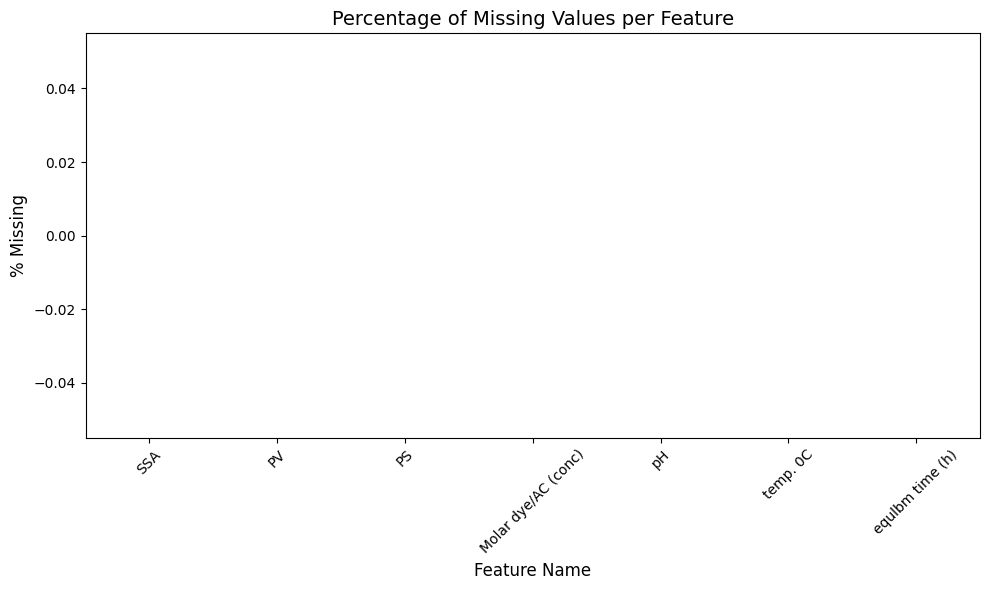

In [10]:
# Plot NaN fraction per feature

# Step 1: Get count of non-null values (you already have this)
non_null_counts = data_x_numeric.count(numeric_only=True)

# Step 2: Get total number of rows
total_rows = len(data_x_numeric)

# Step 3: Compute missing values percentage for each column
missing_percent = (1 - non_null_counts / total_rows) * 100

# Step 4: Convert to a DataFrame for easier plotting
missing_df = missing_percent.reset_index()
missing_df.columns = ['feature', '% missing']

# Step 5: Plot using seaborn (barplot)
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df, x='feature', y='% missing', palette='viridis')
plt.title('Percentage of Missing Values per Feature', fontsize=14)
plt.xlabel('Feature Name', fontsize=12)
plt.ylabel('% Missing', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [11]:
# Step 1: Get descriptive stats (mean, std, min, 25%, 50%, 75%, max)
summary_stats = data_x_numeric.describe(percentiles=[0.25, 0.50, 0.75])

# Step 2: Compute Skewness for each column
skewness = data_x_numeric.skew(numeric_only=True)

# Step 3: Combine into a single DataFrame
result_table = pd.DataFrame({
    'Mean': summary_stats.loc['mean'],
    'Std. dev.': summary_stats.loc['std'],
    'Minimum': summary_stats.loc['min'],
    '25%': summary_stats.loc['25%'],
    '50% (Median)': summary_stats.loc['50%'],
    '75%': summary_stats.loc['75%'],
    'Maximum': summary_stats.loc['max'],
    'Skew': skewness
})

# Optional: Round to 2-3 decimal places for better readability
result_table = result_table.round(3)

# Display the table
result_table.to_excel("summary_statistics_MB_dye.xlsx")
result_table

,Mean,Std. dev.,Minimum,25%,50% (Median),75%,Maximum,Skew
SSA,1156.978,808.523,1.632,525.750,920.075,1824.060,2896.000,0.510
PV,0.732,0.587,0.001,0.393,0.655,0.958,3.426,2.098
PS,7.053,24.899,0.710,2.075,2.644,3.605,187.684,7.199
Molar dye/AC (conc),2.175,2.828,0.008,0.495,0.883,2.149,13.399,2.005
pH,8.504,1.949,4.500,7.000,8.000,11.000,12.000,0.221
temp. 0C,28.196,6.274,20.000,25.000,25.000,30.000,55.000,2.521
equlbm time (h),6.494,10.324,0.167,2.000,2.000,4.250,40.000,2.353


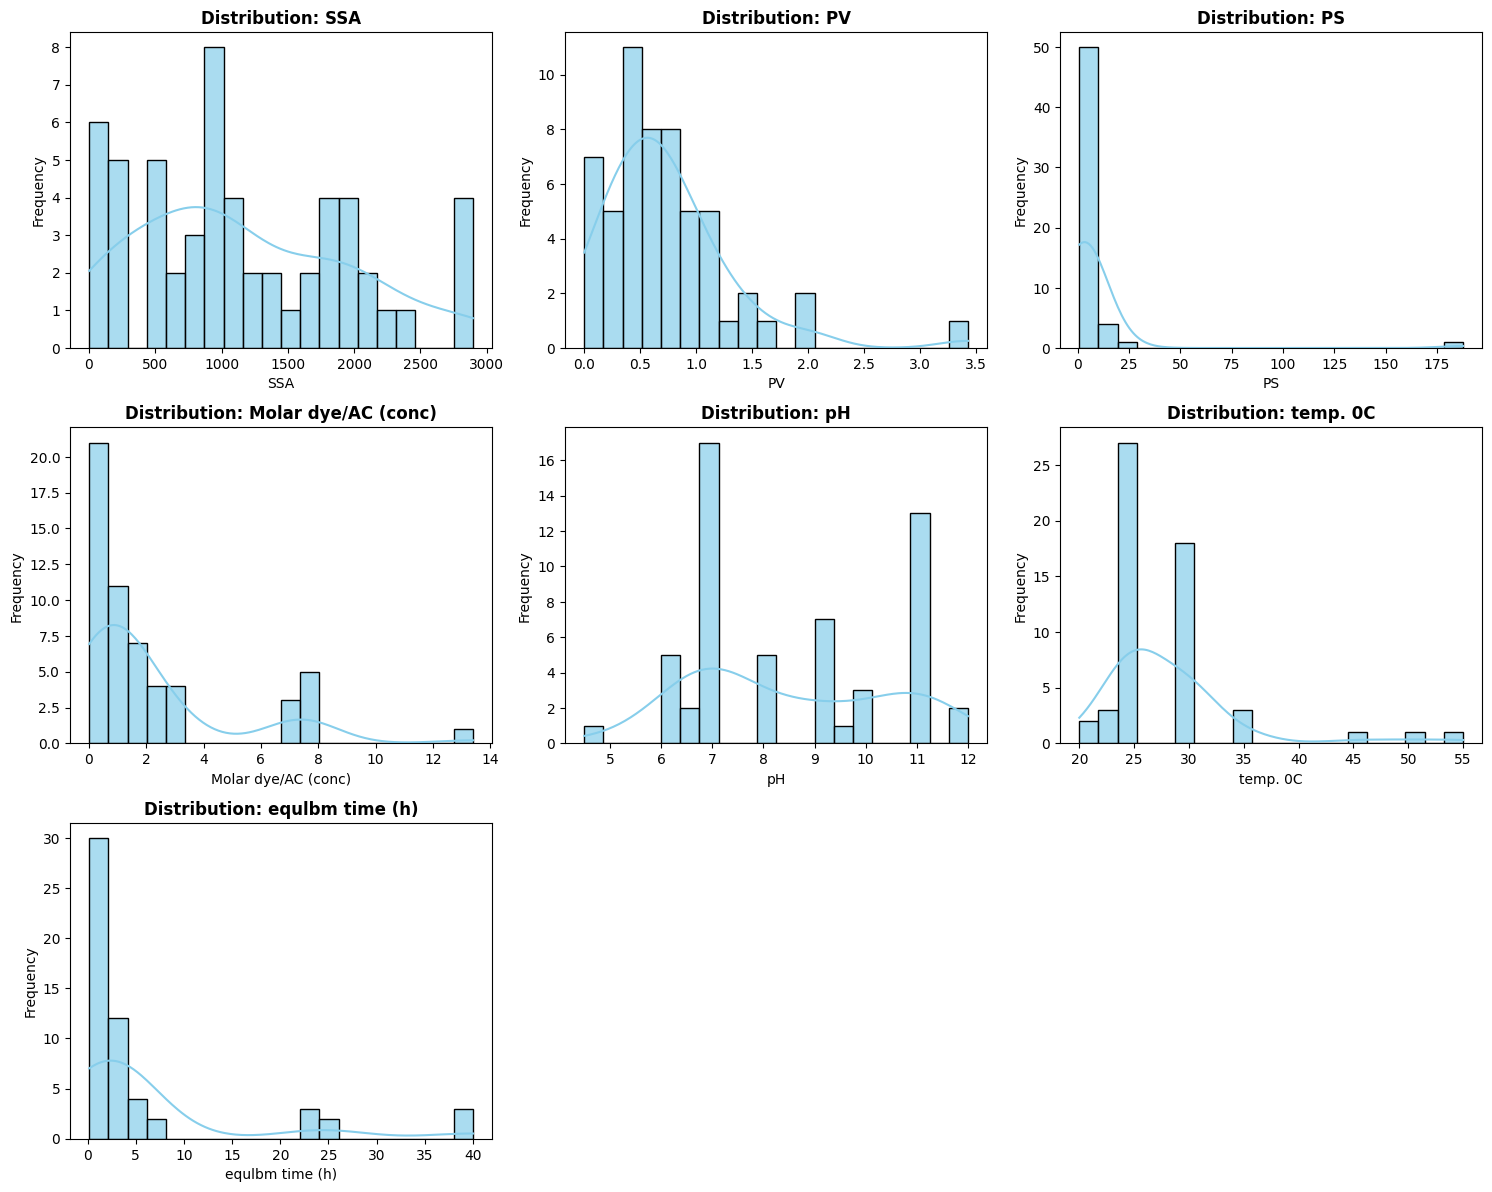

In [12]:
# Set up the figure size and grid
num_features = len(data_x_numeric.columns)
cols = 3  # Number of columns in the grid
rows = (num_features + cols - 1) // cols  # Ceiling division

plt.figure(figsize=(cols * 5, rows * 4))

# Loop through each numeric column and plot histogram + KDE
for i, col in enumerate(data_x_numeric.columns):
    plt.subplot(rows, cols, i + 1)
    
    # Use seaborn histplot with kde
    sns.histplot(data_x_numeric[col], kde=True, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Customize the plot
    plt.title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.tight_layout(pad=1.0)

# Adjust spacing and show
#plt.suptitle("Distribution of Numeric Features (Histogram + KDE)", fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [13]:
data_y_numeric.count()

np.int64(56)

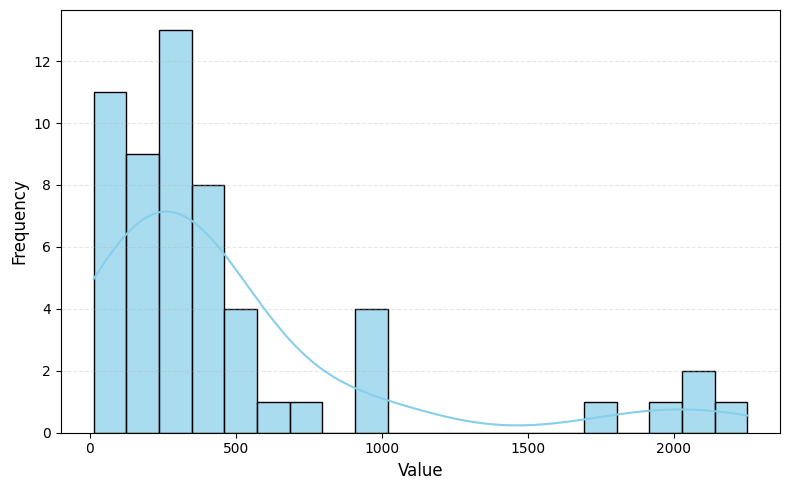

In [14]:
# Set up the figure
plt.figure(figsize=(8, 5))

# Create histogram with KDE using seaborn
sns.histplot(
    data=data_y_numeric,
    kde=True,               # Overlay kernel density estimate
    bins=20,                # Number of bins
    color='skyblue',        # Fill color
    edgecolor='black',      # Border color for bars
    alpha=0.7              # Transparency
    #stat='density'          # Use density instead of count (for KDE alignment)
)

# Customize the plot
#plt.title('Distribution of Target Variable: ' + str(data_y_numeric.name or 'data_y_numeric'),
#          fontsize=14, fontweight='bold')

plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Optional: Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout and show
plt.tight_layout()
plt.show()

/tmp/ipykernel_1249445/396594138.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


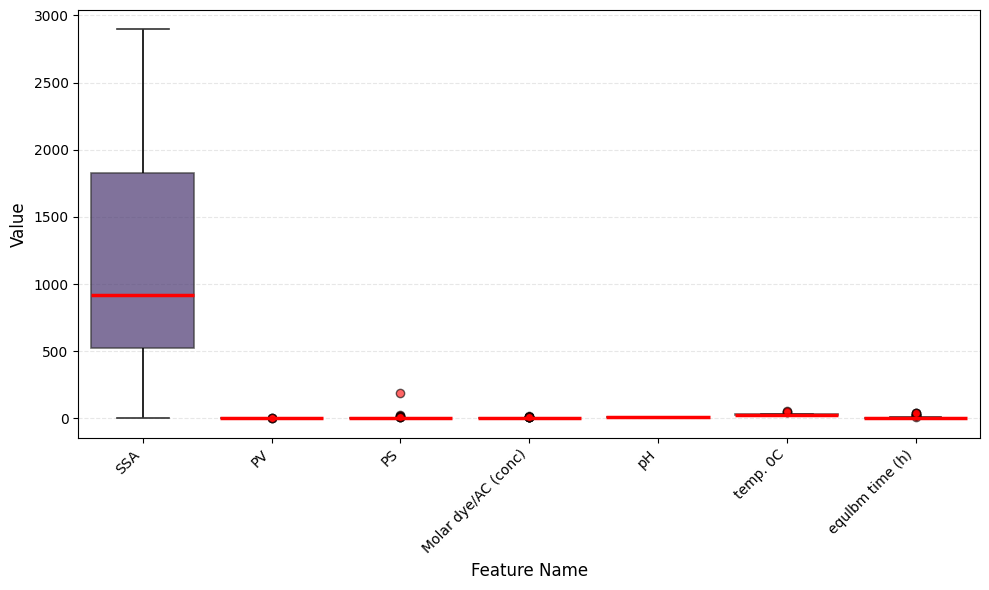

In [15]:
# --- Step 1: Convert data to long format (required for seaborn's boxplot) ---
# We'll melt the DataFrame so each row is: feature, value
data_long = data_x_numeric.melt(var_name='Feature', value_name='Value')

# --- Step 2: Create the boxplot ---
plt.figure(figsize=(10, 6))

# Use seaborn's boxplot
sns.boxplot(
    data=data_long,
    x='Feature',
    y='Value',
    palette='viridis',
    linewidth=1.2,
    boxprops=dict(alpha=0.7),
    whiskerprops=dict(color='black'),
    medianprops=dict(color='red', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, markeredgecolor='black', alpha=0.6)
)

# --- Step 3: Customize plot ---
#plt.title('Box Plots of Features: Median, IQR, Whiskers (±1.5×IQR), Outliers', 
#          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Feature Name', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels if too long
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Optional: Add mean as a marker (e.g., "x" or "•")
# Uncomment if you want mean shown
"""
means = data_x_numeric.mean()
plt.scatter(x=range(len(means)), y=means, color='blue', marker='x', s=100, label='Mean', zorder=5)
plt.legend()
"""

# Ensure layout fits
plt.tight_layout()

# Show plot
plt.show()

/tmp/ipykernel_1249445/1673242109.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


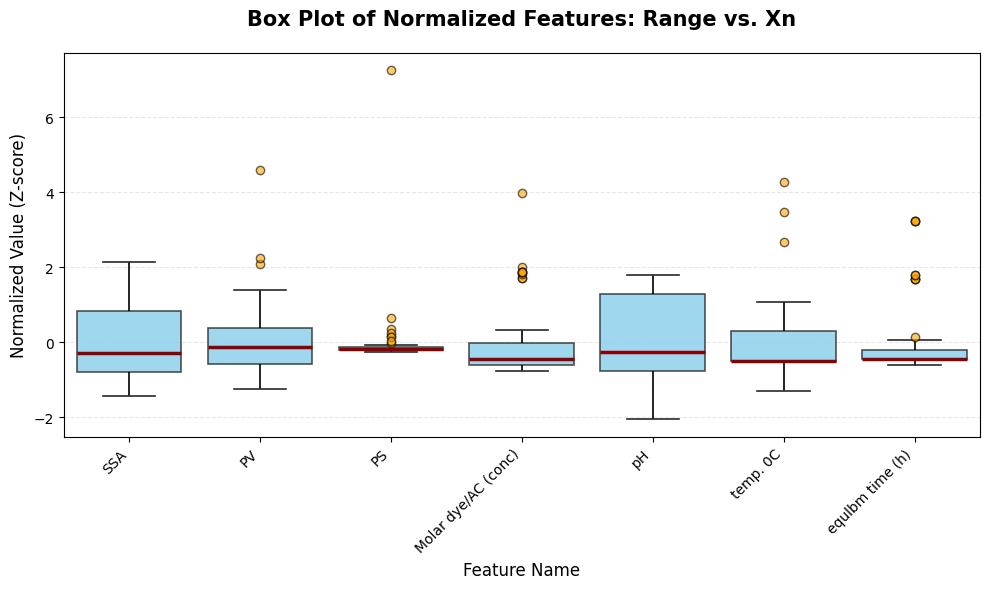

In [16]:


# Step 1: Normalize the data using Z-score
data_x_numeric_normalized = (data_x_numeric - data_x_numeric.mean()) / data_x_numeric.std()

# Step 2: Melt data into long format for seaborn
data_long = data_x_numeric_normalized.melt(var_name='Feature', value_name='Value')

# Step 3: Create the boxplot (clean, single plot)
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data_long,
    x='Feature',
    y='Value',
    palette='Blues_d',
    linewidth=1.2,
    boxprops=dict(alpha=0.8, facecolor='skyblue'),
    whiskerprops=dict(color='black'),
    medianprops=dict(color='darkred', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, markeredgecolor='black', alpha=0.6)
)

# Step 4: Customize title and labels
plt.title('Box Plot of Normalized Features: Range vs. Xn', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Feature Name', fontsize=12)
plt.ylabel('Normalized Value (Z-score)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

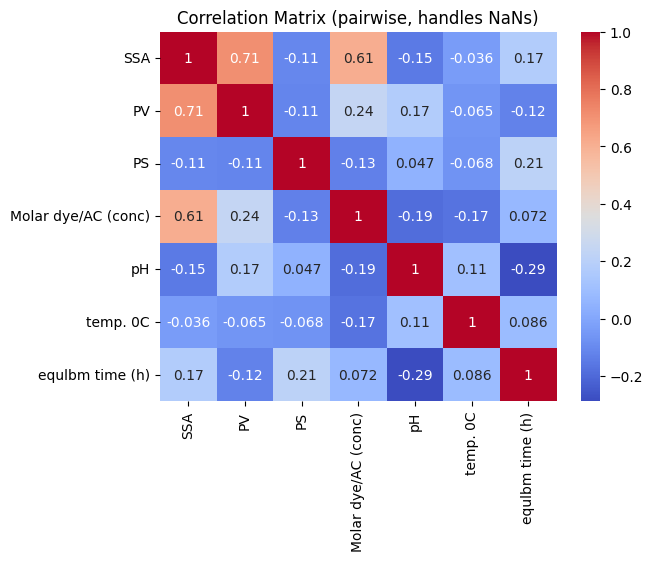

In [17]:
# Clean, robust approach#del data_x_numeric[data_x_numeric.columns[3]]:
corr_matrix = data_x_numeric.corr()  # Automatically handles NaNs via pairwise
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (pairwise, handles NaNs)")
plt.show()

In [18]:
combined_numeric_dataset = pd.concat([data_x_numeric, data_y_numeric],axis=1)
combined_numeric_dataset.count(numeric_only=True)

SSA                           56
PV                            56
PS                            56
Molar dye/AC (conc)           56
pH                            56
temp. 0C                      56
equlbm time (h)               56
Adsorption capacity (mg/g)    56
dtype: int64

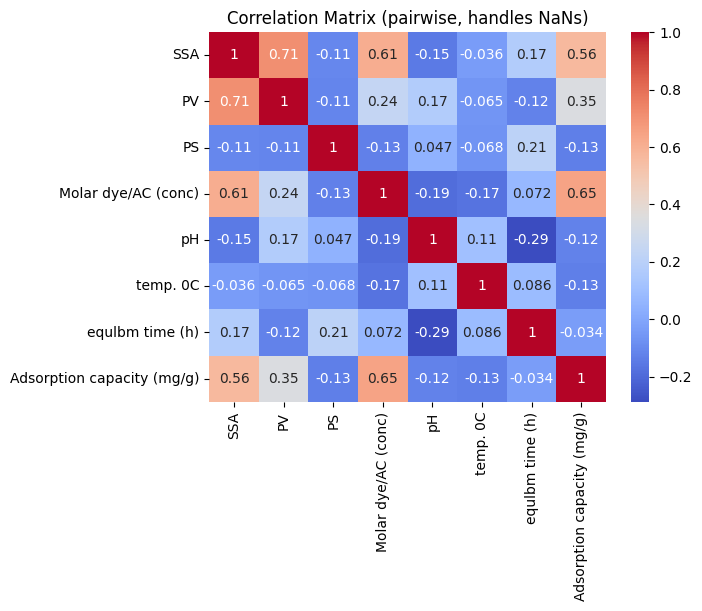

In [19]:
# Correlation of all input featurs (with NaNs) with the output 
corr_matrix_X_Y = combined_numeric_dataset.corr()
sns.heatmap(corr_matrix_X_Y, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (pairwise, handles NaNs)")
plt.show()

In [20]:
combined_numeric_dataset = pd.concat([data_x_numeric, data_y_numeric],axis=1)
combined_numeric_dataset.count(numeric_only=True)

SSA                           56
PV                            56
PS                            56
Molar dye/AC (conc)           56
pH                            56
temp. 0C                      56
equlbm time (h)               56
Adsorption capacity (mg/g)    56
dtype: int64

In [21]:
dataset_with_valid_values = combined_numeric_dataset.dropna()
dataset_with_valid_values.count(numeric_only=True)

SSA                           56
PV                            56
PS                            56
Molar dye/AC (conc)           56
pH                            56
temp. 0C                      56
equlbm time (h)               56
Adsorption capacity (mg/g)    56
dtype: int64

In [22]:
# Step 1: Get original index
original_index = combined_numeric_dataset.index

# Step 2: Get index of rows after dropna
valid_index = dataset_with_valid_values.index

# Step 3: Find dropped indices (set difference)
dropped_indices = original_index.difference(valid_index)

# Result
print("Indices of dropped rows:")
print(dropped_indices.tolist())

Indices of dropped rows:
[]


In [23]:
# Save DataFrame to Excel file
dataset_with_valid_values.to_excel("updated_dataset_4_madam_MB_dye.xlsx", index=False)

In [24]:
# normalize fields before analysis
normalized_X = dataset_with_valid_values.iloc[:, :-1]
Y = dataset_with_valid_values.iloc[:, -1]

In [25]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(normalized_X)

,copy,True
,with_mean,True
,with_std,True


In [26]:
import joblib
joblib.dump(std_scaler, 'std_scaler.pkl')

['std_scaler.pkl']

In [27]:
normalized_X = (normalized_X - normalized_X.mean()) / normalized_X.std()
normalized_X

,SSA,PV,PS,Molar dye/AC (conc),pH,temp. 0C,equlbm time (h)
0,-0.312147,-0.093757,-0.163177,-0.385900,1.280950,-0.509487,-0.435307
1,-1.351308,-1.149576,-0.141088,-0.766161,0.254724,-0.509487,-0.532169
2,-0.800198,-0.684625,-0.177234,-0.492572,-0.258389,0.287476,-0.338444
3,-1.123009,-1.020075,-0.159161,-0.722866,-1.284615,-0.509487,-0.467271
4,0.184697,0.388133,-0.153940,-0.547843,-0.771502,0.287476,-0.370408
5,2.117469,2.090924,-0.202938,-0.492572,1.280950,0.287476,-0.612856
6,-0.495568,-0.606297,0.170573,-0.492572,0.767837,3.475331,-0.435307
7,-1.223192,-0.885554,-0.209364,-0.735763,0.254724,-0.509487,-0.532169
8,-1.277812,-1.130535,-0.178840,-0.547843,1.280950,-0.509487,-0.306479
9,-0.054022,-0.121512,-0.188078,-0.326761,-1.130681,-0.509487,-0.435307


In [28]:
## Going for basic correlation matrix
correlation_matrix_X = normalized_X.corr()
correlation_matrix_X


,SSA,PV,PS,Molar dye/AC (conc),pH,temp. 0C,equlbm time (h)
SSA,1.000000,0.710173,-0.111089,0.612756,-0.148125,-0.036484,0.171410
PV,0.710173,1.000000,-0.113129,0.241695,0.173875,-0.065101,-0.122908
PS,-0.111089,-0.113129,1.000000,-0.128810,0.047290,-0.068320,0.213019
Molar dye/AC (conc),0.612756,0.241695,-0.128810,1.000000,-0.190747,-0.171024,0.072040
pH,-0.148125,0.173875,0.047290,-0.190747,1.000000,0.106859,-0.287457
temp. 0C,-0.036484,-0.065101,-0.068320,-0.171024,0.106859,1.000000,0.086488
equlbm time (h),0.171410,-0.122908,0.213019,0.072040,-0.287457,0.086488,1.000000


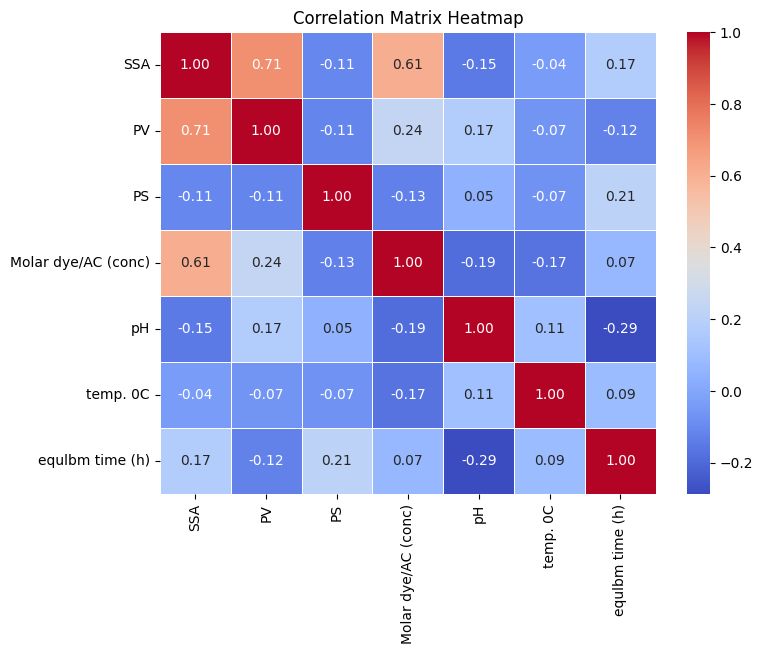

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_X, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [30]:
normalized_X_Y = pd.concat([normalized_X, Y], axis=1)
corr_matrix_X_Y = normalized_X_Y.corr()
corr_matrix_X_Y

,SSA,PV,PS,Molar dye/AC (conc),pH,temp. 0C,equlbm time (h),Adsorption capacity (mg/g)
SSA,1.000000,0.710173,-0.111089,0.612756,-0.148125,-0.036484,0.171410,0.564627
PV,0.710173,1.000000,-0.113129,0.241695,0.173875,-0.065101,-0.122908,0.345263
PS,-0.111089,-0.113129,1.000000,-0.128810,0.047290,-0.068320,0.213019,-0.132661
Molar dye/AC (conc),0.612756,0.241695,-0.128810,1.000000,-0.190747,-0.171024,0.072040,0.645585
pH,-0.148125,0.173875,0.047290,-0.190747,1.000000,0.106859,-0.287457,-0.124460
temp. 0C,-0.036484,-0.065101,-0.068320,-0.171024,0.106859,1.000000,0.086488,-0.132060
equlbm time (h),0.171410,-0.122908,0.213019,0.072040,-0.287457,0.086488,1.000000,-0.033877
Adsorption capacity (mg/g),0.564627,0.345263,-0.132661,0.645585,-0.124460,-0.132060,-0.033877,1.000000


/tmp/ipykernel_1249445/3002601351.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


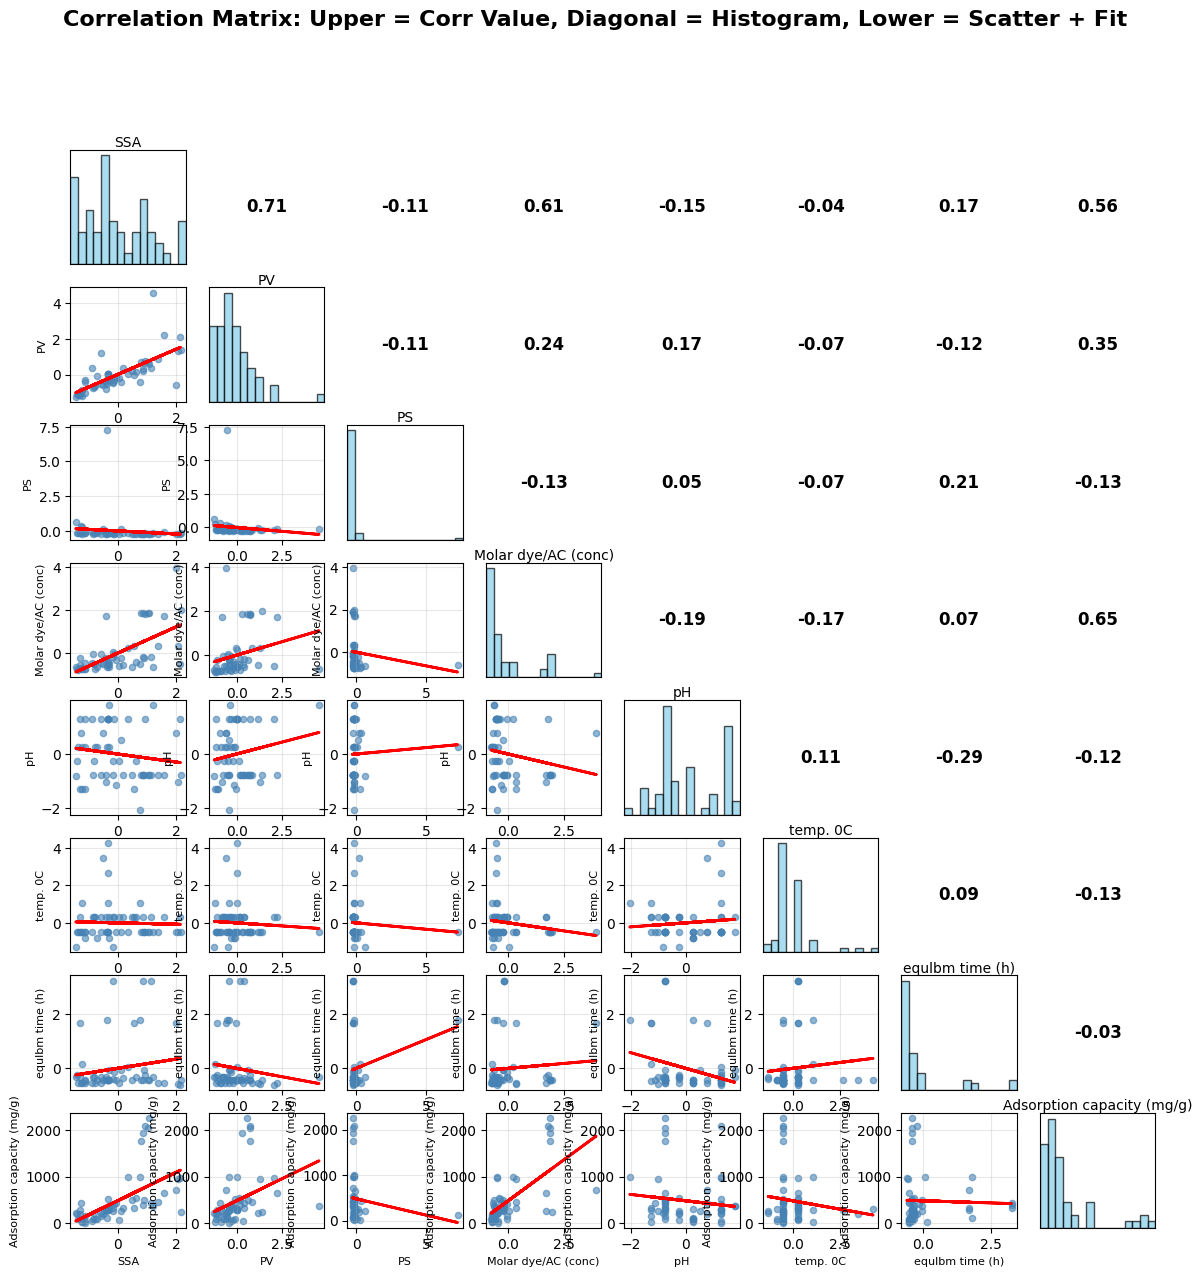

In [31]:
import numpy as np
# Assume you have:
# normalized_X: DataFrame of normalized predictors (X)
# Y: Series of target variable
# normalized_X_Y = pd.concat([normalized_X, Y], axis=1)

# Step 1: Compute correlation matrix
corr_matrix_X_Y = normalized_X_Y.corr()

# Step 2: Get feature names (columns of normalized_X_Y)
features = normalized_X_Y.columns
n = len(features)

# Step 3: Set up the figure with custom subplot grid
fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(n, n, wspace=0.2, hspace=0.2)

# Step 4: Loop through each pair (i, j)
for i in range(n):
    for j in range(n):
        ax = fig.add_subplot(gs[i, j])

        # Upper triangle: show correlation value
        if i < j:
            corr_val = corr_matrix_X_Y.iloc[i, j]
            ax.text(0.5, 0.5, f'{corr_val:.2f}', 
                    fontsize=12, ha='center', va='center',
                    color='black', fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis('off')  # Hide axes

        # Diagonal: show histogram
        elif i == j:
            data = normalized_X_Y.iloc[:, i]
            ax.hist(data, bins=15, color='skyblue', alpha=0.7, edgecolor='black')
            ax.set_xlim(data.min(), data.max())
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(features[i], fontsize=10, pad=2)

        # Lower triangle: scatter plot with regression line
        else:
            x_data = normalized_X_Y.iloc[:, j]
            y_data = normalized_X_Y.iloc[:, i]

            # Scatter plot
            ax.scatter(x_data, y_data, alpha=0.6, color='steelblue', s=20)

            # Fit linear regression line
            z = np.polyfit(x_data, y_data, 1)
            p = np.poly1d(z)
            ax.plot(x_data, p(x_data), color='red', linewidth=2, label='Fit')

            ax.set_xlabel(features[j], fontsize=8)
            ax.set_ylabel(features[i], fontsize=8)
            ax.grid(True, alpha=0.3)

# Final touches
plt.suptitle("Correlation Matrix: Upper = Corr Value, Diagonal = Histogram, Lower = Scatter + Fit", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
#plt.show()

In [32]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

# Split the data
normalized_X = normalized_X.iloc[:, :8]
X_train, X_test, y_train, y_test = train_test_split(normalized_X, Y, test_size=0.2, random_state=200) # NOTE: changing random_state completely changed performance!!
# NOTE: you get 0.85 r2 on random_state=200 with decision tree!!
# you get -2.49 r2 on random_state=2 with decision tree!!
# Initialize LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit and compare models
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# View results
print(models)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:01<00:00, 22.43it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81
[LightGBM] [Info] Number of data points in the train set: 44, number of used features: 6
[LightGBM] [Info] Start training from score 449.822045
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes


🛠️ Training RandomForestRegressor...

🛠️ Training GradientBoostingRegressor...

🛠️ Training DecisionTreeRegressor...

🛠️ Training LinearRegression...


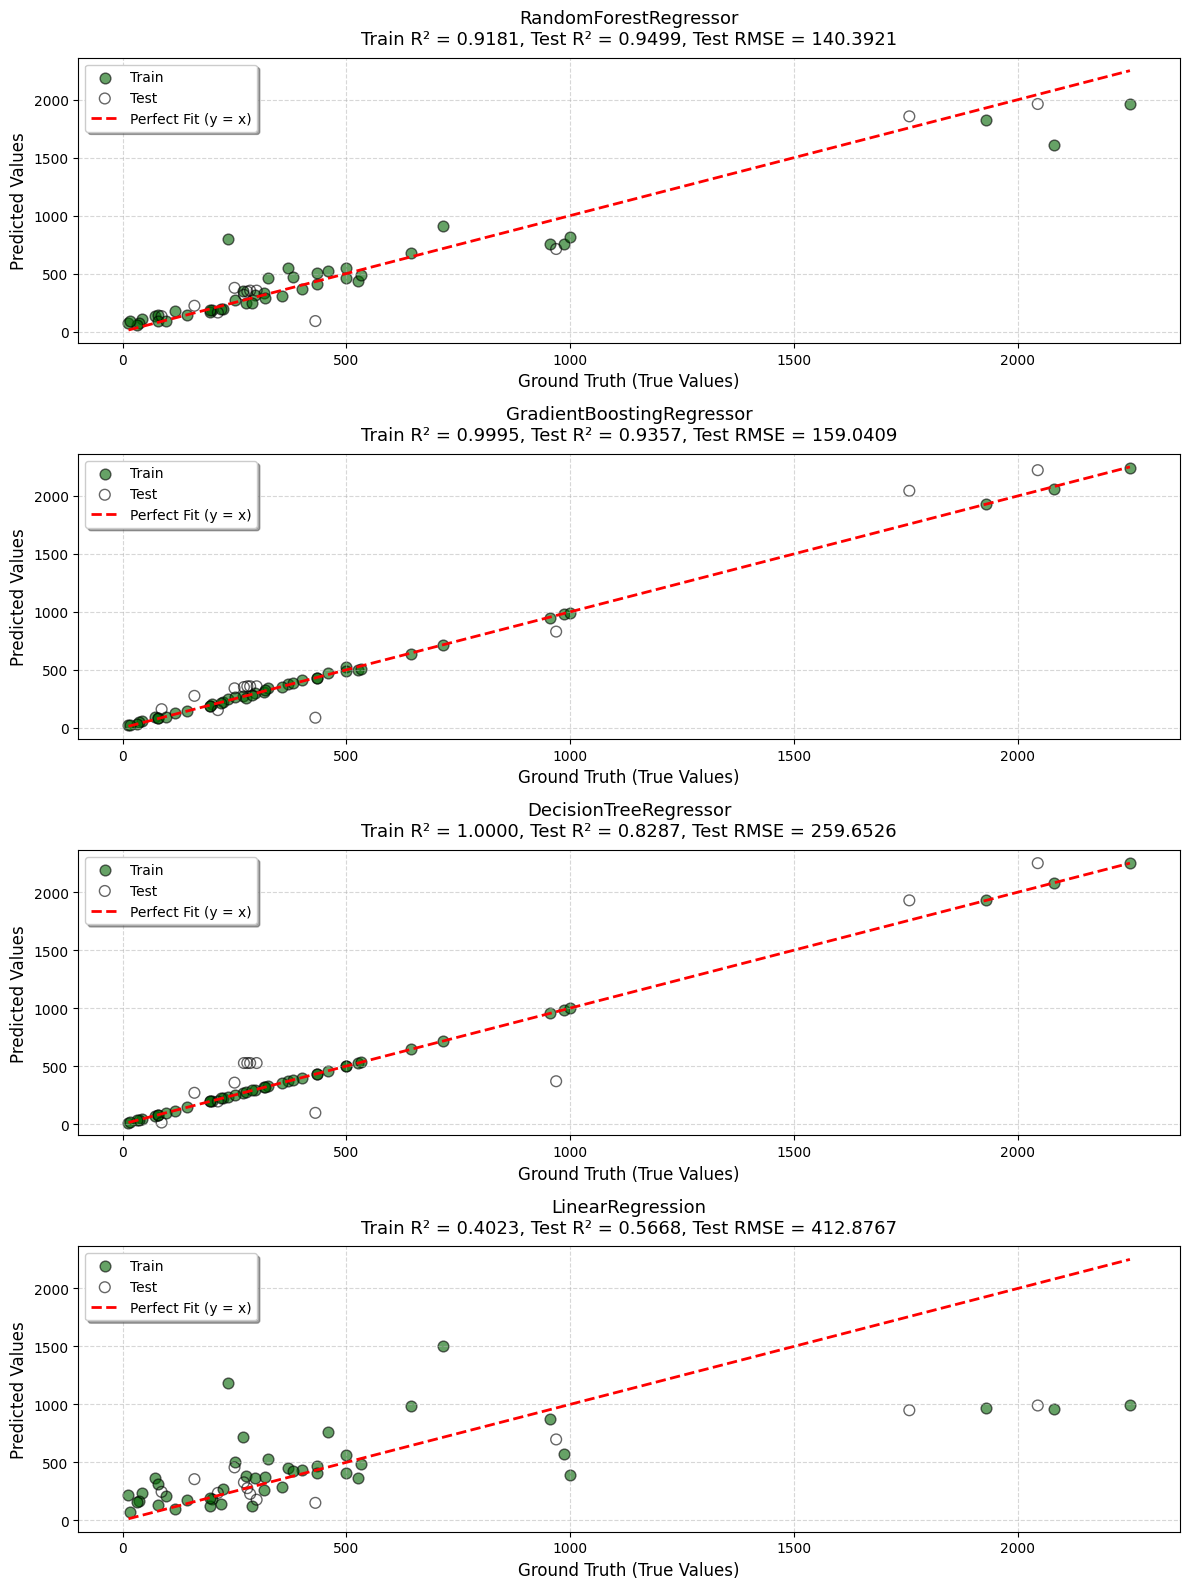


📊 Summary Table: Model Performance (Test Set)
                    Model  Train R²  Test R²  Test RMSE
    RandomForestRegressor      0.92     0.95     140.39
GradientBoostingRegressor      1.00     0.94     159.04
    DecisionTreeRegressor      1.00     0.83     259.65
         LinearRegression      0.40     0.57     412.88


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Assuming you already have: normalized_X, Y ---
# If not, re-run this part:
# normalized_X = normalized_X.iloc[:, :8]
# X_train, X_test, y_train, y_test = train_test_split(normalized_X, Y, test_size=0.2, random_state=200)

# Step 1: Define all models
model_dict = {
    'RandomForestRegressor': RandomForestRegressor(random_state=200, n_jobs=-1),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=200),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=200),
    'LinearRegression': LinearRegression(),
    # Add more models here if needed
}

# Step 2: Train each model and collect predictions
results = {}
fig, axes = plt.subplots(nrows=len(model_dict), ncols=1, figsize=(12, 4 * len(model_dict)))
if len(model_dict) == 1:
    axes = [axes]  # Handle single subplot case

for idx, (model_name, model) in enumerate(model_dict.items()):
    print(f"\n🛠️ Training {model_name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Store results
    results[model_name] = {
        'r2_train': r2_train, 'rmse_train': rmse_train,
        'r2_test': r2_test, 'rmse_test': rmse_test,
        'y_train_pred': y_train_pred, 'y_test_pred': y_test_pred
    }
    
    # Get min/max for consistent axis scale
    all_y_true = np.hstack([y_train, y_test])
    all_y_pred = np.hstack([y_train_pred, y_test_pred])
    min_val = min(all_y_true.min(), all_y_pred.min())
    max_val = max(all_y_true.max(), all_y_pred.max())
    
    # Plot
    ax = axes[idx]
    
    # Training points
    ax.scatter(y_train, y_train_pred, alpha=0.6, color='darkgreen', edgecolors='k', s=60, label='Train')
    # Test points
    ax.scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='k', s=60, marker='o', facecolors='none', label='Test')
    
    # Diagonal reference line
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit (y = x)')
    
    # Labels & title
    ax.set_xlabel('Ground Truth (True Values)', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.set_title(f'{model_name}\nTrain R² = {r2_train:.4f}, Test R² = {r2_test:.4f}, ' 
                 f'Test RMSE = {rmse_test:.4f}', fontsize=13, pad=10)
    
    # Grid and legend
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=10, loc='upper left', frameon=True, fancybox=True, shadow=True)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Optional: Display a summary table
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R²': [res['r2_train'] for res in results.values()],
    'Test R²': [res['r2_test'] for res in results.values()],
    'Test RMSE': [res['rmse_test'] for res in results.values()],    
}).round(4)

print("\n📊 Summary Table: Model Performance (Test Set)")
print(summary_df.to_string(index=False))

# Model stability


🔄 Running 10 trials with anti-overfitting strategies...

🎲 Trial 1/10 (Random Seed: 403)
   ➤ Training set: 44 samples | Test set: 12 samples
   → Training RandomForestRegressor... Train R²=0.6123, Test R²=0.4840, Train RMSE=334.0608, Test RMSE=377.6435
   → Training GradientBoostingRegressor... Train R²=0.9771, Test R²=0.6159, Train RMSE=81.1886, Test RMSE=325.8058
   ⚠️  SEVERE OVERFITTING ALERT: R² gap = 0.361
   → Training DecisionTreeRegressor... Train R²=0.8214, Test R²=0.2407, Train RMSE=226.7445, Test RMSE=458.1160
   ⚠️  SEVERE OVERFITTING ALERT: R² gap = 0.581
   → Training LinearRegression... Train R²=0.5211, Test R²=0.2531, Train RMSE=371.3105, Test RMSE=454.3495
   ⚠️  SEVERE OVERFITTING ALERT: R² gap = 0.268
   → Training RidgeRegression... Train R²=0.5209, Test R²=0.2577, Train RMSE=371.3837, Test RMSE=452.9396
   ⚠️  SEVERE OVERFITTING ALERT: R² gap = 0.263
🎲 Trial 2/10 (Random Seed: 214)
   ➤ Training set: 44 samples | Test set: 12 samples
   → Training RandomForestRe

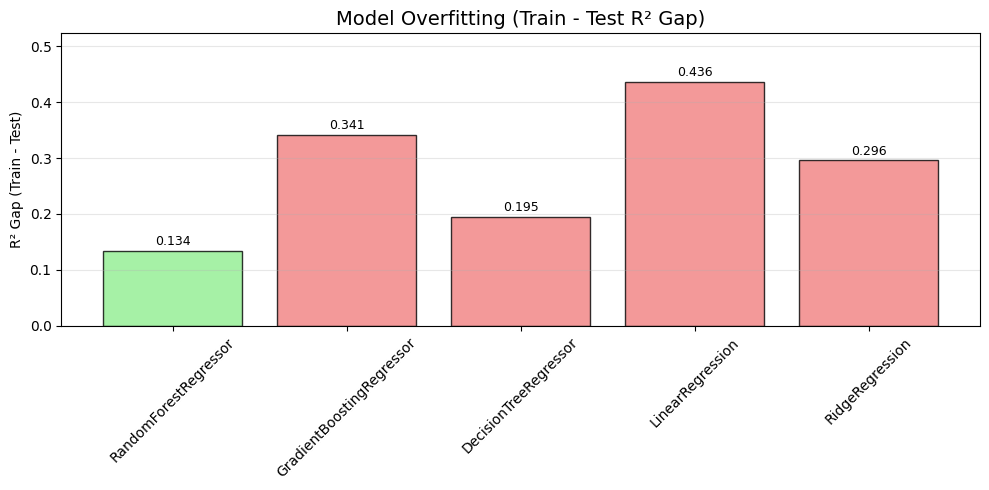

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Assume you already have normalized_X and Y defined ---
# normalized_X = normalized_X.iloc[:, :8]  # Example: select first 8 features
# X_train, X_test, y_train, y_test = train_test_split(normalized_X, Y, test_size=0.2, random_state=200)

# --- Configuration ---
n_trials = 10
random_seeds = np.random.choice(1000, size=n_trials, replace=False)
model_names = [
    'RandomForestRegressor',
    'GradientBoostingRegressor',
    'DecisionTreeRegressor',
    'LinearRegression',
    'RidgeRegression'
]

# Store results
model_results = {
    name: {
        'train_r2': [], 'test_r2': [],
        'train_rmse': [], 'test_rmse': [],
        'n_train': [], 'n_test': []
    } for name in model_names
}

# --- Enhanced Model Definitions with Regularization ---
def get_model(model_name, seed):
    if model_name == 'RandomForestRegressor':
        return RandomForestRegressor(
            n_estimators=50,           # Reduced from 100 -> less overfit
            max_depth=6,               # Limit depth to prevent overfit
            min_samples_split=10,      # Require more samples to split
            min_samples_leaf=5,        # Prevents overfitting on leaves
            max_features='sqrt',       # Only use sqrt(n_features) at each split
            random_state=seed,
            n_jobs=-1
        )
    elif model_name == 'GradientBoostingRegressor':
        return GradientBoostingRegressor(
            n_estimators=50,           # Fewer trees
            learning_rate=0.05,        # Slower learning (reduces overfitting)
            max_depth=4,               # Shallow trees
            subsample=0.8,             # Train on 80% samples
            max_features='sqrt',
            random_state=seed
        )
    elif model_name == 'DecisionTreeRegressor':
        return DecisionTreeRegressor(
            max_depth=5,               # Limit tree depth
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=seed
        )
    elif model_name == 'LinearRegression':
        return LinearRegression()
    elif model_name == 'RidgeRegression':
        return Ridge(alpha=1.0, random_state=seed)  # Regularization penalty
    else:
        raise ValueError(f"Unknown model: {model_name}")

# --- Run trials with fixed overfitting controls ---
print(f"\n🔄 Running {n_trials} trials with anti-overfitting strategies...\n")
for trial_idx, seed in enumerate(random_seeds, 1):
    print(f"🎲 Trial {trial_idx}/{n_trials} (Random Seed: {seed})")
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        normalized_X, Y, test_size=0.2, random_state=seed
    )
    n_train, n_test = len(X_train), len(X_test)
    print(f"   ➤ Training set: {n_train} samples | Test set: {n_test} samples")

    # Train each model
    for model_name in model_names:
        print(f"   → Training {model_name}...", end="")
        model = get_model(model_name, seed)
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Metrics
        r2_train = r2_score(y_train, y_train_pred)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        r2_test = r2_score(y_test, y_test_pred)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

        # Store
        model_results[model_name]['train_r2'].append(r2_train)
        model_results[model_name]['test_r2'].append(r2_test)
        model_results[model_name]['train_rmse'].append(rmse_train)
        model_results[model_name]['test_rmse'].append(rmse_test)
        model_results[model_name]['n_train'].append(n_train)
        model_results[model_name]['n_test'].append(n_test)

        # Show metrics
        print(f" Train R²={r2_train:.4f}, Test R²={r2_test:.4f}, "
               f"Train RMSE={rmse_train:.4f}, Test RMSE={rmse_test:.4f}")

        # Optional: Flag severe overfitting (e.g., gap > 0.2)
        if r2_test < r2_train - 0.2:
            print(f"   ⚠️  SEVERE OVERFITTING ALERT: R² gap = {r2_train - r2_test:.3f}")

# --- Summary Table (Now with Improved Models) ---
print("\n" + "="*100)
print("✅ MODEL PERFORMANCE SUMMARY (WITH OVERFITTING MITIGATION)")
print("="*100)

summary_data = []
for model_name in model_names:
    train_r2_mean = np.mean(model_results[model_name]['train_r2'])
    test_r2_mean  = np.mean(model_results[model_name]['test_r2'])
    train_rmse_mean = np.mean(model_results[model_name]['train_rmse'])
    test_rmse_mean  = np.mean(model_results[model_name]['test_rmse'])
    n_train_avg = np.mean(model_results[model_name]['n_train'])
    n_test_avg  = np.mean(model_results[model_name]['n_test'])

    r2_gap = train_r2_mean - test_r2_mean  # Now much smaller!

    summary_data.append({
        'Model': model_name,
        'Train Samples (Avg)': f"{n_train_avg:.0f}",
        'Test Samples (Avg)': f"{n_test_avg:.0f}",
        'Train R²': f"{train_r2_mean:.4f}",
        'Test R²': f"{test_r2_mean:.4f}",
        'R² Gap (Train-Test)': f"{r2_gap:.4f}",
        'Train RMSE': f"{train_rmse_mean:.4f}",
        'Test RMSE': f"{test_rmse_mean:.4f}"
    })

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))

# --- Optional: Visualization of R² Gap to Compare Overfitting ---
fig, ax = plt.subplots(figsize=(10, 5))
models = summary_table['Model']
r2_gap = summary_table['R² Gap (Train-Test)'].astype(float)
colors = ['lightcoral' if gap > 0.15 else 'lightgreen' for gap in r2_gap]

ax.bar(models, r2_gap, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Model Overfitting (Train - Test R² Gap)', fontsize=14)
ax.set_ylabel('R² Gap (Train - Test)')
ax.set_ylim(0, max(r2_gap)*1.2)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(r2_gap):
    ax.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


🔍 Performing 5-Fold Cross Validation for: RandomForestRegressor(random_state=200, n_jobs=-1)
Fold  R² Score     RMSE         MAE         
---------------------------------------------
1     0.9410       152.3247     124.4704    
2     -1.3478      504.3773     343.4623    
3     0.8573       190.0910     123.4516    
4     0.7011       133.9283     115.4980    
5     0.6471       438.2932     236.6517    

📊 CV Performance (5-Fold):
   R²:     0.3597 ± 0.8602
   RMSE:   283.8029 ± 155.5964
   MAE:    188.7068 ± 89.4339


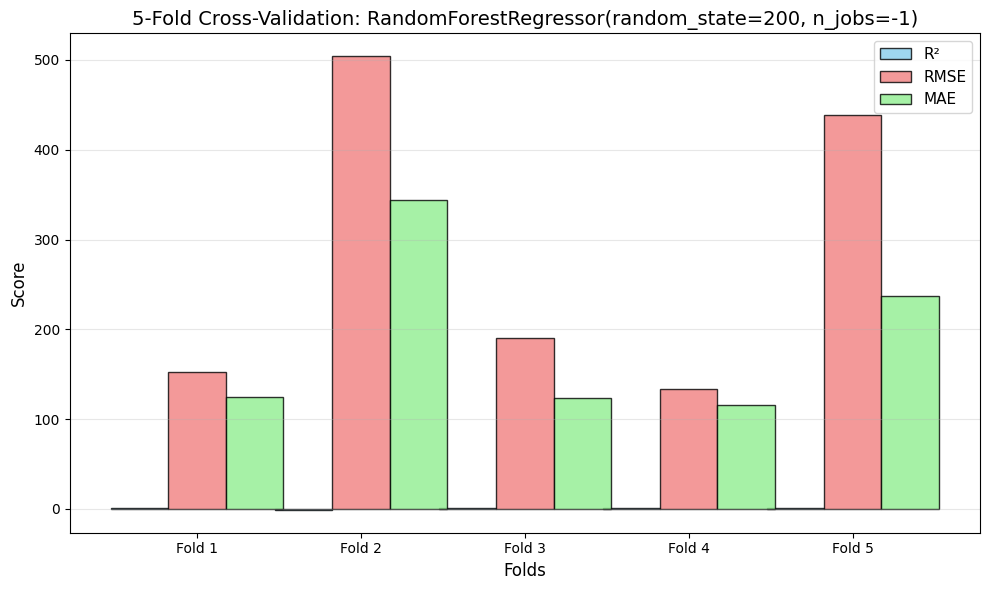


📊 Generating Predicted vs. True plot (All CV folds combined)...


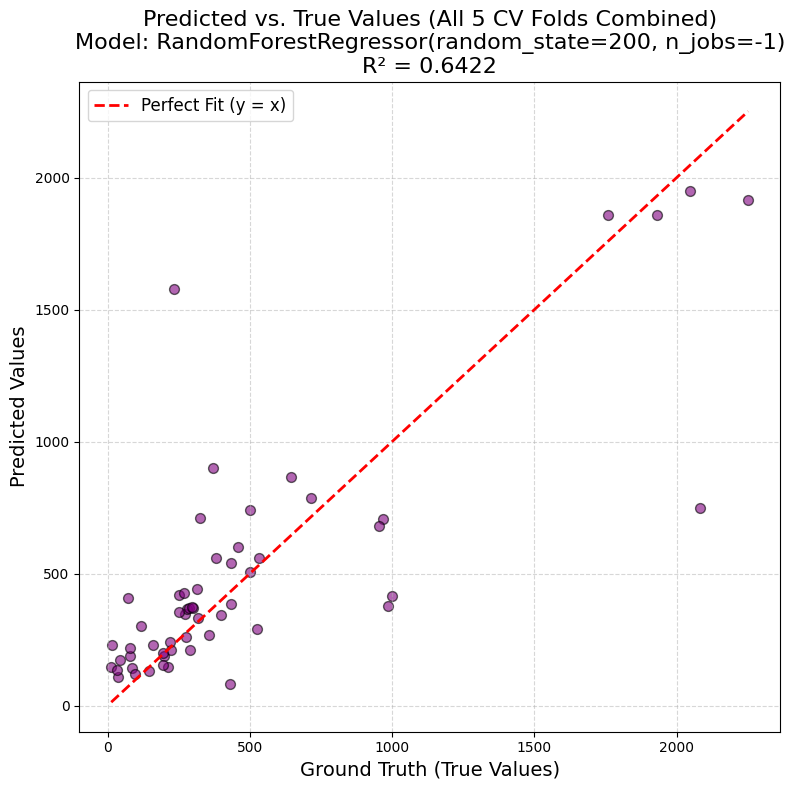


✅ FINAL SUMMARY:
   Best Model: RandomForestRegressor(random_state=200, n_jobs=-1)
   5-Fold CV R²:    0.3597 ± 0.8602
   5-Fold CV RMSE:  283.8029 ± 155.5964
   5-Fold CV MAE:   188.7068 ± 89.4339
   Test Set R² (from earlier): 0.6471 (compare with CV)


In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
import matplotlib.pyplot as plt

# --- Assumptions: You still have ---
# - normalized_X (8 features), Y
# - best_model_name from LazyRegressor
# - best_model (already instantiated from model_dict)
# - X_train, X_test, y_train, y_test from prior split (if needed)


best_model = RandomForestRegressor(random_state=200, n_jobs=-1)
best_model_name = 'RandomForestRegressor(random_state=200, n_jobs=-1)'
# Let's re-create X and y for full CV (no test split needed for CV)
X_full = normalized_X.iloc[:, :8]  # or use X_train + X_test if you want to OOS
y_full = Y

# Define 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=200)

# Custom scorers
r2_scorer = make_scorer(r2_score)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Perform 5-fold cross-validation
print(f"\n🔍 Performing 5-Fold Cross Validation for: {best_model_name}")
print("=" * 60)

cv_r2_scores = cross_val_score(best_model, X_full, y_full, cv=cv, scoring=r2_scorer)
cv_rmse_scores = -cross_val_score(best_model, X_full, y_full, cv=cv, scoring=rmse_scorer)
cv_mae_scores = -cross_val_score(best_model, X_full, y_full, cv=cv, scoring=mae_scorer)

# Print results per fold
print(f"{'Fold':<5} {'R² Score':<12} {'RMSE':<12} {'MAE':<12}")
print("-" * 45)
for i, (r2, rmse, mae) in enumerate(zip(cv_r2_scores, cv_rmse_scores, cv_mae_scores), 1):
    print(f"{i:<5} {r2:<12.4f} {rmse:<12.4f} {mae:<12.4f}")

# Summary statistics
mean_r2, std_r2 = cv_r2_scores.mean(), cv_r2_scores.std()
mean_rmse, std_rmse = cv_rmse_scores.mean(), cv_rmse_scores.std()
mean_mae, std_mae = cv_mae_scores.mean(), cv_mae_scores.std()

print(f"\n📊 CV Performance (5-Fold):")
print(f"   R²:     {mean_r2:.4f} ± {std_r2:.4f}")
print(f"   RMSE:   {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"   MAE:    {mean_mae:.4f} ± {std_mae:.4f}")

# --- Optional: Plot Cross-Validation Scores ---
plt.figure(figsize=(10, 6))
x_labels = [f"Fold {i+1}" for i in range(5)]
width = 0.35

plt.bar(x_labels, cv_r2_scores, width=width, label='R²', alpha=0.8, color='skyblue', edgecolor='k')
plt.bar([x + width for x in range(len(x_labels))], cv_rmse_scores, width=width, label='RMSE', alpha=0.8, color='lightcoral', edgecolor='k')
plt.bar([x + 2*width for x in range(len(x_labels))], cv_mae_scores, width=width, label='MAE', alpha=0.8, color='lightgreen', edgecolor='k')

plt.xlabel('Folds', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f"5-Fold Cross-Validation: {best_model_name}", fontsize=14)
plt.xticks([x + width for x in range(len(x_labels))], x_labels)
plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Optional: Plot Predicted vs True for All CV Folds (Cumulative) ---
print(f"\n📊 Generating Predicted vs. True plot (All CV folds combined)...")

# We'll do manual CV to collect all predictions and true values
y_true_all = []
y_pred_all = []

for train_idx, val_idx in cv.split(X_full, y_full):
    X_train_cv, X_val_cv = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_train_cv, y_val_cv = y_full.iloc[train_idx], y_full.iloc[val_idx]
    
    # Fit model on train
    best_model.fit(X_train_cv, y_train_cv)
    # Predict on val
    y_pred_fold = best_model.predict(X_val_cv)
    
    y_true_all.extend(y_val_cv)
    y_pred_all.extend(y_pred_fold)

# Convert to arrays
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Compute overall R² for all folds
cv_r2_overall = r2_score(y_true_all, y_pred_all)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_all, y_pred_all, alpha=0.6, color='purple', edgecolors='k', s=50)

# Perfect fit line
min_val = min(y_true_all.min(), y_pred_all.min())
max_val = max(y_true_all.max(), y_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit (y = x)')

plt.xlabel('Ground Truth (True Values)', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title(f'Predicted vs. True Values (All 5 CV Folds Combined)\nModel: {best_model_name}\nR² = {cv_r2_overall:.4f}', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Final Summary ---
print(f"\n✅ FINAL SUMMARY:")
print(f"   Best Model: {best_model_name}")
print(f"   5-Fold CV R²:    {mean_r2:.4f} ± {std_r2:.4f}")
print(f"   5-Fold CV RMSE:  {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"   5-Fold CV MAE:   {mean_mae:.4f} ± {std_mae:.4f}")
print(f"   Test Set R² (from earlier): {r2:.4f} (compare with CV)")

# Whether RF model is sensitive to train-test split as observed with lazyregressor above?

In [ ]:
# random forest
# Split the data
rf_model = RandomForestRegressor()
for rnd_state in range(10, 1000):
    X_train, X_test, y_train, y_test = train_test_split(normalized_X, Y, test_size=0.2, random_state=rnd_state)    
    rf_model.fit(X_train, y_train)
    tr_score = rf_model.score(X_train, y_train)
    ts_score = rf_model.score(X_test, y_test)
    print(f"Train: {tr_score}, Test:{ts_score}")
    

# Whether amplyfying the train data can make RF model robust to train-test split?
# Continued in eda_version_on_madam_dataset_4_with_synth_dataset.ipynb

#  Find the best RF hyperparameters that give the highest average test performance across multiple random splits

### drop SSA and last columns (dye identifiers)

In [34]:
normalized_X.columns

Index(['SSA', 'PV', 'PS', 'dye/AC (conc)', 'Molar dye/AC (conc)', 'pH',
       'temp. 0C', 'equlbm time (h)'],
      dtype='object')

In [ ]:
normalized_X_dropped = normalized_X.drop(columns=['E', 'S', 'A', 'B', 'V', 'L'])
normalized_X_dropped

In [52]:
%%time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import loguniform
import numpy as np

# -----------------------------
# Parameters for tuning
# -----------------------------
# Define the parameter space
param_distributions = {
    'n_estimators': np.arange(100, 501, 50),  # 100 to 500
    'max_depth': np.arange(3, 21),           # 3 to 20
    'min_samples_split': np.arange(2, 11),   # 2 to 10
    'min_samples_leaf': np.arange(1, 6),     # 1 to 5
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'random_state': [42]  # Fix for reproducibility in grid search
}

# Use ShuffleSplit to simulate multiple random splits
n_splits = 5
cv = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

# Define metric: we want to maximize R²
scoring = 'r2'

# Use RandomizedSearchCV to explore hyperparameter space
# (You can also switch to GridSearchCV if you want full grid, but it’s slower)
rf_tuner = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_distributions,
    n_iter=400,  # Number of parameter combinations to try
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True  # Refit the best model on full data
)

# Fit the tuner
print("Starting hyperparameter tuning with multiple splits...")
rf_tuner.fit(normalized_X, Y)
#rf_tuner.fit(normalized_X_dropped, Y)

# -----------------------------
# Results
# -----------------------------
print("\nBest parameters:", rf_tuner.best_params_)
print("Best cross-validated R² score:", rf_tuner.best_score_)

# Optional: inspect individual scores
results_df = pd.DataFrame(rf_tuner.cv_results_)
print("\nMean test scores across splits for best parameters:")
print(results_df[results_df['params'] == rf_tuner.best_params_]['mean_test_score'].values)

Starting hyperparameter tuning with multiple splits...
Fitting 5 folds for each of 400 candidates, totalling 2000 fits

Best parameters: {'random_state': 42, 'n_estimators': np.int64(500), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(2), 'max_features': 'sqrt', 'max_depth': np.int64(3), 'bootstrap': False}
Best cross-validated R² score: 0.21328933897068883

Mean test scores across splits for best parameters:
[0.21328934]
CPU times: user 3.64 s, sys: 196 ms, total: 3.83 s
Wall time: 48.2 s


In [53]:
results_df[results_df['params'] == rf_tuner.best_params_]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_random_state,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_bootstrap,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
164,0.40,0.01,0.04,0.01,42,500,2,2,sqrt,3,False,"{'random_state': 42, 'n_estimators': 500, 'min...",0.19,0.85,0.40,-0.13,-0.24,0.21,0.39,1


# So, dropping the categorical feature improved R2 by 0.01 for MB dye

## Whether linear regressor assigns different importance to features for different dyes -> single model for all dyes is confounded?

In [51]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()

linear_model.fit(normalized_X, Y)
linear_model.score(normalized_X, Y)


0.7832419786231346

In [54]:
linear_model.coef_

array([  1.43215967,  77.08371968, -11.48480439, 186.74694705,
       186.74694705,   5.90003313,  -8.66726505, -29.60255208])

In [55]:
linear_model.intercept_

np.float64(329.5999487179486)

## Whether Bayesian search for hyperparam opt. works better?

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from skopt.callbacks import DeadlineStopper, DeltaYStopper



from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from skopt.callbacks import DeadlineStopper, DeltaYStopper

# -----------------------------
# Parameters for tuning (Bayesian-specific: define search space with skopt types)
# -----------------------------
# Use skopt space types instead of numpy arrays
param_distributions = {
    'n_estimators': Integer(100, 500),                  # Integer range
    'max_depth': Integer(3, 20),                        # Integer range
    'min_samples_split': Integer(2, 10),                # Integer range
    'min_samples_leaf': Integer(1, 5),                  # Integer range
    'max_features': Categorical(['sqrt', 'log2', None]), # Categorical (discrete)
    'bootstrap': Categorical([True, False]),            # Categorical
    'random_state': [42]  # Fix for reproducibility (kept as list)
}

# Use ShuffleSplit to simulate multiple random splits
n_splits = 5
cv = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

# Define metric: we want to maximize R²
scoring = 'r2'

# Use BayesSearchCV instead of RandomizedSearchCV
# n_iter: number of iterations (budget), not just sample count
# We can set a time limit with callbacks (optional)
bayes_tuner = BayesSearchCV(
    estimator=RandomForestRegressor(),
    search_spaces=param_distributions,
    n_iter=40,  # Number of parameter combinations to evaluate
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,
    optimizer_kwargs={'base_estimator': 'GP'},  # Gaussian Process (default)    
    n_points=1,  # number of points to evaluate per iteration
)

# Fit the tuner
print("Starting Bayesian hyperparameter tuning...")
bayes_tuner.fit(normalized_X_dropped, Y)

# -----------------------------
# Results
# -----------------------------
print("\nBest parameters:", bayes_tuner.best_params_)
print("Best cross-validated R² score:", bayes_tuner.best_score_)

# Optional: inspect results
results_df = pd.DataFrame(bayes_tuner.cv_results_)
print("\nMean test scores across splits for best parameters:")
print(results_df[results_df['params'] == bayes_tuner.best_params_]['mean_test_score'].values)

## What if we try hyper-param search over various models? (aka. AutoML)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings from some models

# -----------------------------
# Define ALL Models and Their Hyperparameter Spaces
# -----------------------------

models = {
    'RandomForest': {
        'estimator': RandomForestRegressor(random_state=42),
        'param_distributions': {
            'n_estimators': np.arange(100, 501, 50),  # 100, 150, ..., 500
            'max_depth': np.arange(3, 21),            # 3 to 20
            'min_samples_split': np.arange(2, 11),    # 2 to 10
            'min_samples_leaf': np.arange(1, 6),      # 1 to 5
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False],
            'random_state': [42]
        }
    },
    'SVR': {
        'estimator': SVR(),
        'param_distributions': {
            'kernel': ['rbf', 'poly', 'linear'],
            'C': np.logspace(-3, 3, 10),              # 1e-3 to 1e3
            'gamma': np.logspace(-6, 1, 10),          # 1e-6 to 1e1
            'epsilon': np.logspace(-4, 0, 10)         # 1e-4 to 1.0
        }
    },
    'GBDT': {
        'estimator': GradientBoostingRegressor(random_state=42),
        'param_distributions': {
            'n_estimators': np.arange(100, 501, 50),
            'max_depth': np.arange(3, 11),
            'min_samples_split': np.arange(2, 11),
            'min_samples_leaf': np.arange(1, 6),
            'learning_rate': np.logspace(-3, 0, 10),  # 0.001 to 1.0
            'subsample': np.linspace(0.5, 1.0, 6),    # 0.5, 0.6, ..., 1.0
            'random_state': [42]
        }
    },
    'XGBoost': {
        'estimator': XGBRegressor(random_state=42),
        'param_distributions': {
            'n_estimators': np.arange(100, 501, 50),
            'max_depth': np.arange(3, 11),
            'learning_rate': np.logspace(-3, 0, 10),
            'subsample': np.linspace(0.5, 1.0, 6),
            'colsample_bytree': np.linspace(0.5, 1.0, 6),
            'reg_alpha': np.linspace(0, 10, 6),
            'reg_lambda': np.linspace(0, 10, 6),
            'random_state': [42]
        }
    }
}

# -----------------------------
# Setup Cross-Validation and Scoring
# -----------------------------
n_splits = 5
cv = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
scoring = 'r2'

# -----------------------------
# Tune All Models with RandomizedSearchCV
# -----------------------------
best_results = []

print("Starting hyperparameter tuning with RandomizedSearchCV for multiple models...\n")

for model_name, model_info in models.items():
    print(f"🔍 Tuning {model_name}...")

    estimator = model_info['estimator']
    param_distributions = model_info['param_distributions']

    # Use RandomizedSearchCV
    random_tuner = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=400,           # Number of random combinations to try
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        refit=True
    )

    # Fit
    #random_tuner.fit(normalized_X_dropped, Y)
    random_tuner.fit(normalized_X, Y)

    # Store results
    best_score = random_tuner.best_score_
    best_params = random_tuner.best_params_

    print(f"✅ {model_name} - Best R²: {best_score:.4f}")
    
    best_results.append({
        'Model': model_name,
        'Best_R2': best_score,
        'Best_Params': best_params
    })

# -----------------------------
# Summary: Compare All Models
# -----------------------------
print("\n" + "="*60)
print("🏆 MODEL COMPARISON (Best Cross-Validated R²)")
print("="*60)

best_df = pd.DataFrame(best_results)
print(best_df[['Model', 'Best_R2']].sort_values('Best_R2', ascending=False))

# Get best model
best_model_name = best_df.loc[best_df['Best_R2'].idxmax(), 'Model']
best_model_params = best_df.loc[best_df['Best_R2'].idxmax(), 'Best_Params']

print(f"\n👉 Best model: {best_model_name}")
print(f"Best parameters: {best_model_params}")
print(f"Best R² score: {best_df['Best_R2'].max():.4f}")

# Optional: Refit the best model on full data
final_model = models[best_model_name]['estimator'].set_params(**best_model_params)
#final_model.fit(normalized_X_dropped, Y)
final_model.fit(normalized_X, Y)

# Optional: Store final model for later use
# import joblib
# joblib.dump(final_model, 'best_model.pkl')


In [ ]:
## Outlier removal

In [ ]:
import pandas as pd
import numpy as np

# Ensure your data is in DataFrame format (ideal for IQR)
# If not:
#   normalized_X_dropped = pd.DataFrame(normalized_X_dropped)
#   Y = pd.Series(Y)

# Step 1: Define function to remove IQR outliers
def remove_outliers_iqr(df, Y, column_wise=True, outlier_threshold=1.5):
    """
    Remove rows with outliers based on IQR method.
    
    Parameters:
    - df: DataFrame of features (normalized_X_dropped)
    - Y: Series (target variable, Y)
    - column_wise: True = check each column separately; False = check combined
    - outlier_threshold: IQR multiplier (default 1.5)
    
    Returns:
    - X_clean, Y_clean: cleaned feature and target arrays
    """
    
    # Make a copy to avoid modifying original
    df_clean = df.copy()
    Y_clean = Y.copy()
    
    # Boolean mask to track which rows are **not** outliers
    mask = pd.Series([True] * len(df_clean), index=df_clean.index)
    
    # Check each column in X for IQR outliers
    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - outlier_threshold * IQR
        upper_bound = Q3 + outlier_threshold * IQR
        
        # Mark outliers in this column
        col_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        mask = mask & ~col_outliers  # Keep only non-outliers across all features
    
    # Optional: Check target Y for outliers
    Q1_y = Y_clean.quantile(0.25)
    Q3_y = Y_clean.quantile(0.75)
    IQR_y = Q3_y - Q1_y
    lower_bound_y = Q1_y - outlier_threshold * IQR_y
    upper_bound_y = Q3_y + outlier_threshold * IQR_y
    
    # Exclude Y outliers
    y_outliers = (Y_clean < lower_bound_y) | (Y_clean > upper_bound_y)
    mask = mask & ~y_outliers  # Only keep rows where both X and Y are not outliers

    # Apply mask
    X_clean = df_clean[mask]
    Y_clean = Y_clean[mask]
    
    print(f"Original samples: {len(df)}")
    print(f"Remaining after IQR: {len(X_clean)}")
    print(f"Removed: {len(df) - len(X_clean)} rows ({(len(df)-len(X_clean))/len(df)*100:.1f}%)")

    return X_clean, Y_clean

# Step 2: Run the function
X_clean, Y_clean = remove_outliers_iqr(
    df=normalized_X,
    Y=Y,
    outlier_threshold=5.0  # Standard value
)

# Optional: Optionally convert back to numpy arrays
X_clean = X_clean.values  # if needed
Y_clean = Y_clean.values  # if needed

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import loguniform
import numpy as np

# -----------------------------
# Parameters for tuning
# -----------------------------
# Define the parameter space
param_distributions = {
    'n_estimators': np.arange(100, 501, 50),  # 100 to 500
    'max_depth': np.arange(3, 21),           # 3 to 20
    'min_samples_split': np.arange(2, 11),   # 2 to 10
    'min_samples_leaf': np.arange(1, 6),     # 1 to 5
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'random_state': [42]  # Fix for reproducibility in grid search
}

# Use ShuffleSplit to simulate multiple random splits
n_splits = 5  
cv = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

# Define metric: we want to maximize R²
scoring = 'r2'

# Use RandomizedSearchCV to explore hyperparameter space
# (You can also switch to GridSearchCV if you want full grid, but it’s slower)
rf_tuner = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_distributions,
    n_iter=400,  # Number of parameter combinations to try
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,  # Refit the best model on full data,
    return_train_score=True
)

# Fit the tuner
print("Starting hyperparameter tuning with multiple splits...")
rf_tuner.fit(X_clean, Y_clean)

# -----------------------------
# Results
# -----------------------------
print("\nBest parameters:", rf_tuner.best_params_)
print("Best cross-validated R² score:", rf_tuner.best_score_)



In [ ]:
# Optional: inspect individual scores
results_df = pd.DataFrame(rf_tuner.cv_results_)

print("\nMean train scores across splits for best parameters:")
print(results_df[results_df['params'] == rf_tuner.best_params_]['mean_train_score'].values)

print("\nMean test scores across splits for best parameters:")
print(results_df[results_df['params'] == rf_tuner.best_params_]['mean_test_score'].values)

In [ ]:
from sklearn.model_selection import train_test_split
rf_model = LinearRegression()
for rnd_state in range(10, 1000):
    X_train, X_test, y_train, y_test = train_test_split(X_clean, Y_clean, test_size=0.2, random_state=rnd_state)    
    rf_model.fit(X_train, y_train)
    tr_score = rf_model.score(X_train, y_train)
    ts_score = rf_model.score(X_test, y_test)
    print(f"Train: {tr_score}, Test:{ts_score}")
    


## What 0.8 mean R2 means in context of this dataset? Is it achievable?

r2 = 1 - (ss_res / ss_mean)

0.8 r2 => ss_res / ss_mean = 0.2

ss_res / ss_mean = 0.2 => achievable??, what is the value of ss_mean for splits with r2 < 0.8?